# Vision Transformers and Transfer Learning

Bean leaf disease is a major threat to food security in Sub-Saharan Africa.
Early, accurate detection of **Angular Leaf Spot** and **Bean Rust** allows farmers
to intervene before an entire crop is lost.
This makes automated image classification
a genuinely impactful task.

In this assignment we compare two fundamentally different strategies for tackling
this classification problem:

| Strategy | Description |
|---|---|
| **CNN from scratch** | A convolutional network trained entirely on the small beans dataset (~1 000 images). No prior knowledge of images is used. |
| **ViT + Transfer Learning** | A Vision Transformer pre-trained on ImageNet (86 M parameter `google/vit-base-patch16-224`), whose weights already encode rich visual representations. We *fine-tune* only the last classification head on the beans data. |

Before running these experiments we first build a hands-on understanding of the
two key ViT primitives: **patch extraction** and **self-attention**.

The notebook is split into three parts:

1. **Part 1 — Guided exercises (Tasks 1–3):** three independent functions that cover the
   core ViT building blocks. Each task has its own self-tests so you can verify your
   solution before moving on.
2. **Part 2 — CNN from Scratch:** a standard convolutional baseline trained entirely on
   the beans dataset for 5 epochs.
3. **Part 3 — Transfer Learning with a Pretrained ViT:** fine-tuning a ViT pre-trained on
   ImageNet for 5 epochs on the same beans data, plus a direct comparison.

We strongly recommend watching the lecture and reviewing the slides before starting.

---

## Grading

Each task asks you to implement one Python function.
**Do not rename any function**, the autograder uses exact name matching.

| Task | Function | Points |
|:-----|:---------|:------:|
| 1 | [`img_to_patch`](#task-1) | 15 |
| 2 | [`compute_attention_matrix`](#task-2) | 15 |
| 3 | [`single_head_attention`](#task-3) | 10 |
| | **Total** | **40** |

---

## Dataset

The [beans dataset](https://huggingface.co/datasets/AI-Lab-Makerere/beans) consists of
**1 034 training**, **133 validation**, and **128 test** photographs of bean leaves,
each labelled with one of three classes:

| Label | Description |
|:------|:-----------|
| `angular_leaf_spot` | Angular brown lesions caused by a bacterial pathogen |
| `bean_rust` | Orange-brown pustules caused by a fungal pathogen |
| `healthy` | No visible disease |

Images vary in size (roughly 500 × 500 px); we resize to 224 × 224 for both models.


## GPU Setup

Training requires a GPU. In Google Colab go to **Runtime → Change runtime type → GPU** before running any cell. Without a GPU, training will be very slow.

In [3]:
# NOTE: Execute this cell once before running any other code.
# It will install the necessary libraries.

!pip install -q datasets transformers evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [4]:
import os, random
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

from datasets import load_dataset
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import confusion_matrix, classification_report

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if "cpu" in str(DEVICE):
    print("\nWARNING: Running on CPU. For faster training, switch to GPU runtime "
          "(Runtime > Change runtime type > GPU).")
else:
    print("\nGood! You are using a GPU for faster training.")

# class names (in label-id order)
CLASS_NAMES = ["angular_leaf_spot", "bean_rust", "healthy"]


Using device: cuda

Good! You are using a GPU for faster training.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


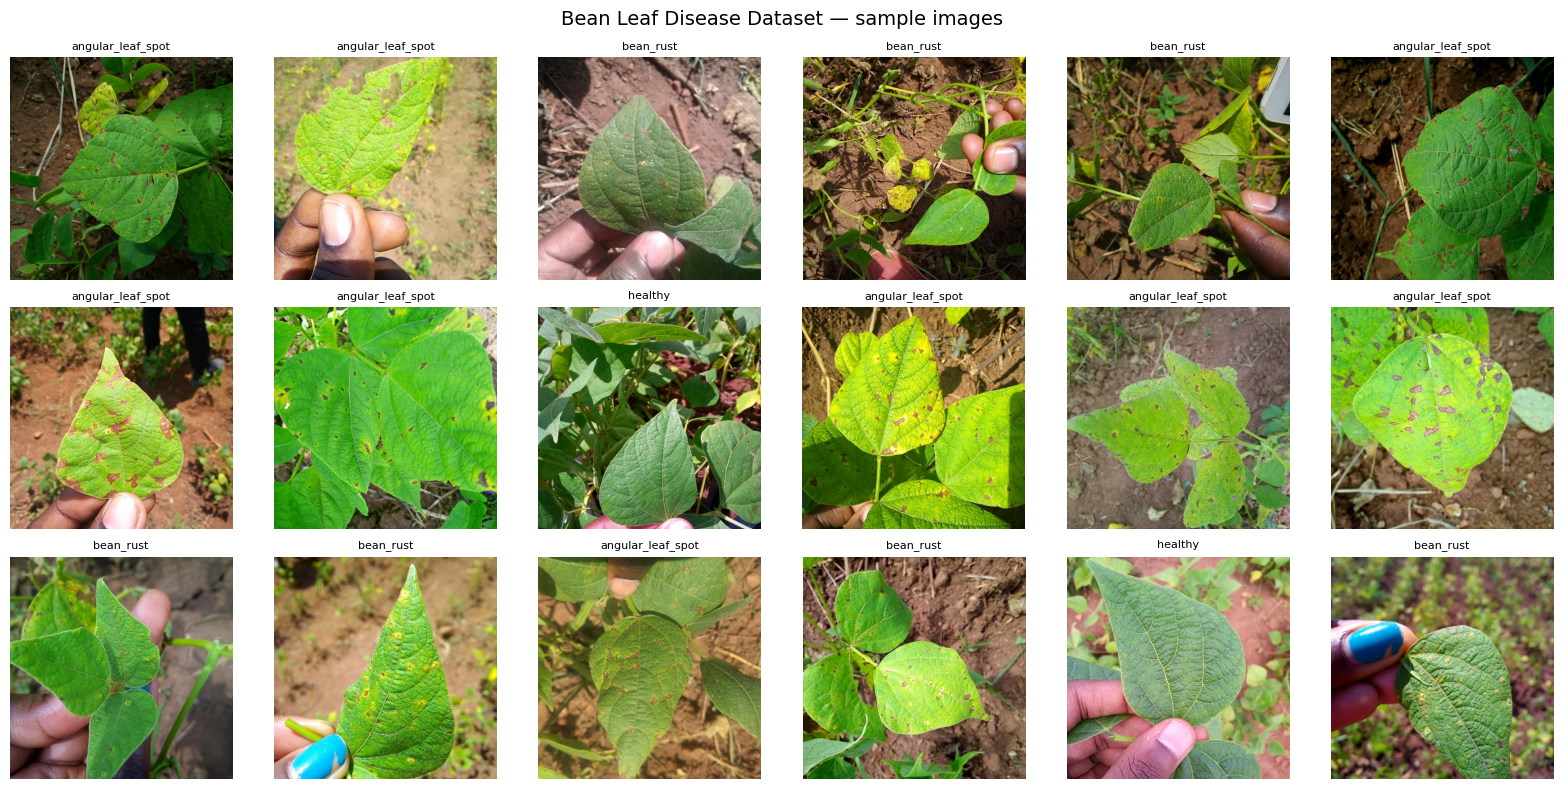


Split sizes -> train: 1034 | val: 133 | test: 128


In [5]:
# ── Load the beans dataset from HuggingFace ──────────────────────────────────
beans = load_dataset("AI-Lab-Makerere/beans")
print(beans)

label_map = beans["train"].features["labels"].int2str  # int -> class name

# ── Visualise a few examples ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle("Bean Leaf Disease Dataset — sample images", fontsize=14)
for col, split in enumerate(["train", "validation", "test"]):
    indices = random.sample(range(len(beans[split])), 6)
    for row, idx in enumerate(indices):
        item  = beans[split][idx]
        img   = item["image"]
        label = label_map(item["labels"])
        axes[col][row].imshow(img)
        axes[col][row].set_title(label, fontsize=8)
        axes[col][row].axis("off")
    axes[col][0].set_ylabel(split.capitalize(), fontsize=10, rotation=90, labelpad=40)
plt.tight_layout()
plt.show()
print(f"\nSplit sizes -> train: {len(beans['train'])} | "
      f"val: {len(beans['validation'])} | test: {len(beans['test'])}")


---

# Part 1 — Core ViT Building Blocks

Before the Transformer encoder ever sees the image, two key operations are performed:

1. **Patch extraction** — the image is divided into a regular grid of non-overlapping
   patches.
2. **Self-attention** — every patch token attends to every other patch, building a
   rich, globally-informed representation.

The three tasks in this section build your intuition for these operations step by step:

| Task | What you build | Role in ViT |
|:-----|:--------------|:-----------|
| 1 | `img_to_patch` | Tokenise the image into a patch sequence |
| 2 | `compute_attention_matrix` | Compute scaled dot-product attention weights |
| 3 | `single_head_attention` | Apply attention weights to value projections |


## Task 1: `img_to_patches` — Patch Extraction

<a id="task-1"></a>

A Vision Transformer processes an image as a sequence of image patches.

Given an input tensor of shape `[B, C, H, W]` and a patch size `M`, split all images within the batch into non-overlapping patches of size `M × M`.

Implement the function `img_to_patches` using only tensor operations (`reshape` / `view`, `permute`, `flatten`). Do not use explicit Python loops.

The function should return a tensor of shape `[B, num_patches, C, M, M]`, where

`num_patches = (H // M) * (W // M)`

and the patches are ordered row-by-row from top-left to bottom-right.


In [6]:
def img_to_patches(x, patch_size):
    """
    Input:
        x: [B, C, H, W]

    Output:
        patches: [B, N, C, P, P]
    """
    ###########################################################################
    # TODO: Implement the function img_to_patches                             #
    ###########################################################################
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    B, C, H, W = x.shape
    P = patch_size
    patches = x.view(
        B, C, H // P, P, W // P, P)

    patches = patches.permute(0, 2, 4, 1, 3, 5)

    patches = patches.reshape(

        B, -1, C, P, P

    )

    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    ###########################################################################

    return patches

In [7]:
img = torch.zeros(1, 3, 32, 32)

img[0, 0, :16, :16] = 1.0      # top-left red
img[0, 2, :16, 16:] = 1.0      # top-right blue
img[0, 1, 16:, :16] = 1.0      # bottom-left green

patches = img_to_patches(img, 16)

print(f"Patch tensor shape: {patches.shape}")
print(f"Expected shape    : torch.Size([1, 4, 3, 16, 16])")
print()

patch0_ok = (
    torch.all(patches[0,0,0] == 1) and
    torch.all(patches[0,0,1] == 0) and
    torch.all(patches[0,0,2] == 0)
)

patch1_ok = (
    torch.all(patches[0,1,0] == 0) and
    torch.all(patches[0,1,1] == 0) and
    torch.all(patches[0,1,2] == 1)
)

patch2_ok = (
    torch.all(patches[0,2,0] == 0) and
    torch.all(patches[0,2,1] == 1) and
    torch.all(patches[0,2,2] == 0)
)

patch3_ok = torch.all(patches[0,3] == 0)

print(f"Patch 0 (top-left, red)      correct: {patch0_ok}")
print(f"Patch 1 (top-right, blue)    correct: {patch1_ok}")
print(f"Patch 2 (bottom-left, green) correct: {patch2_ok}")
print(f"Patch 3 (bottom-right, empty) correct: {patch3_ok}")

all_ok = patch0_ok and patch1_ok and patch2_ok and patch3_ok

print()
print(f"Overall patchification test passed: {all_ok}")

Patch tensor shape: torch.Size([1, 4, 3, 16, 16])
Expected shape    : torch.Size([1, 4, 3, 16, 16])

Patch 0 (top-left, red)      correct: True
Patch 1 (top-right, blue)    correct: True
Patch 2 (bottom-left, green) correct: True
Patch 3 (bottom-right, empty) correct: True

Overall patchification test passed: True


### Visualization: Your `img_to_patch` in Action
The cells below apply your implementation to four real bean-leaf images using a patch
size of 16.  Each image of size 224 × 224 yields **196 patches** (14 × 14 grid),
which are shown flattened into a single horizontal strip.


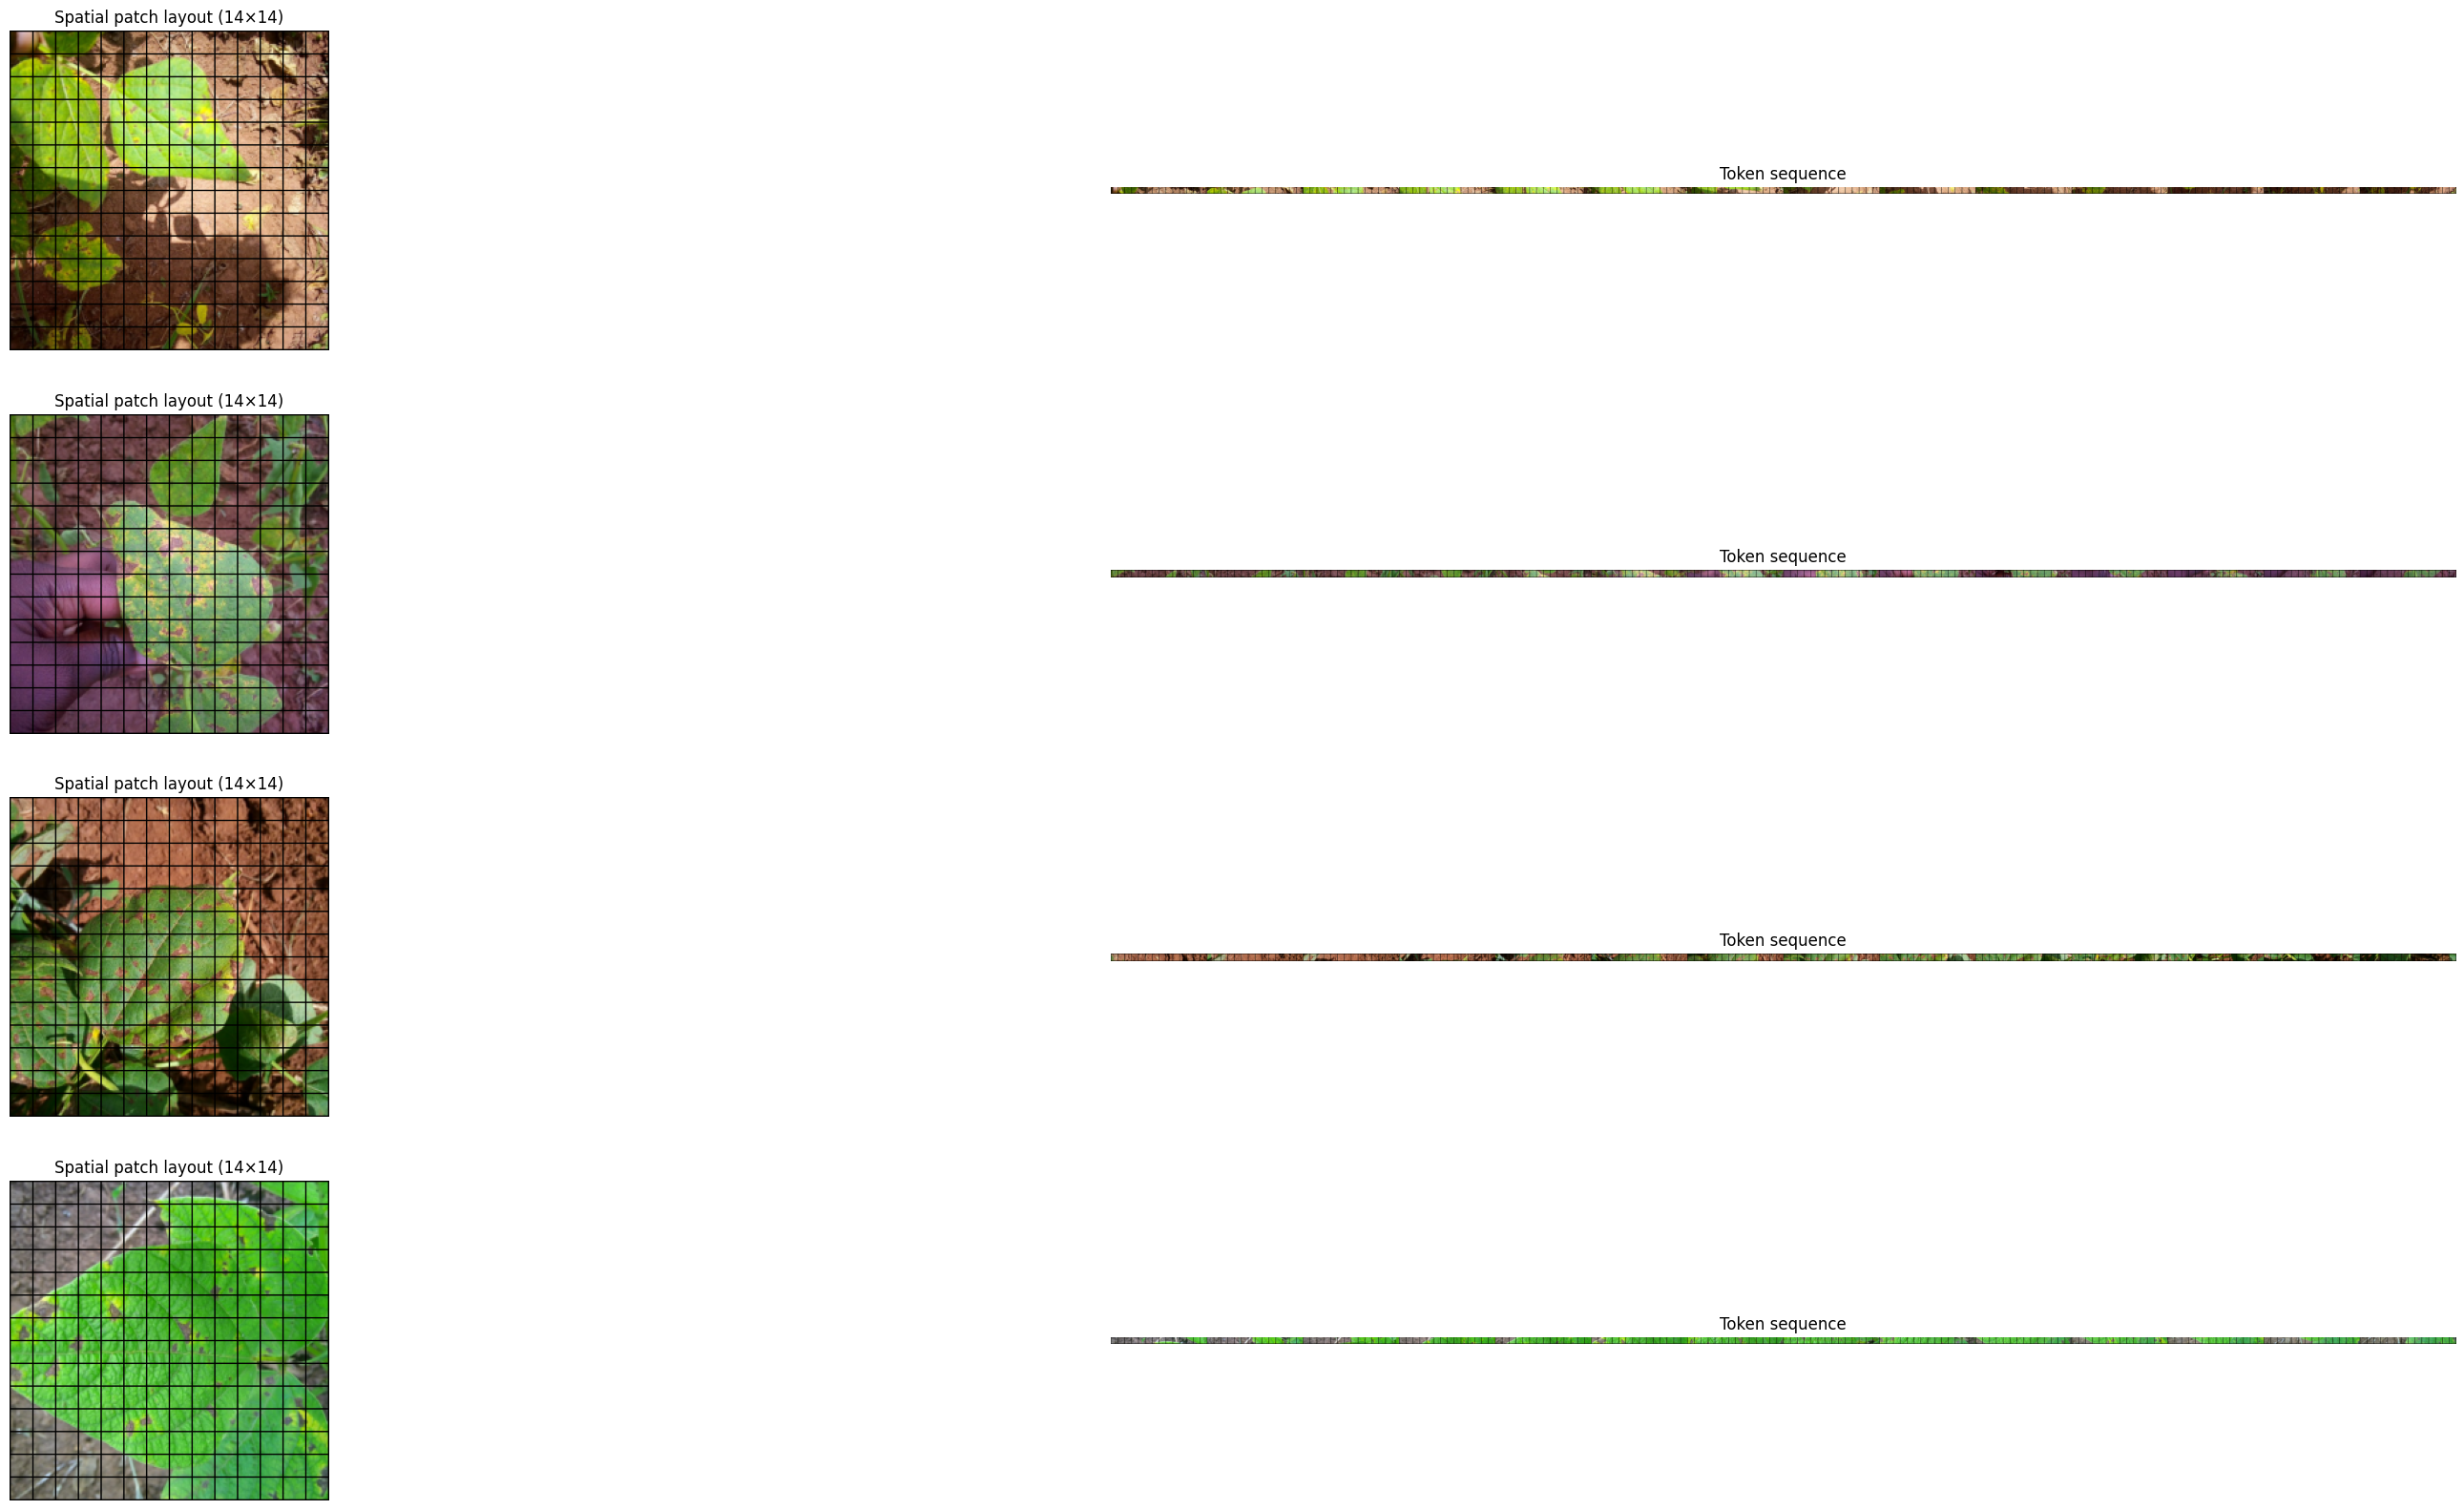

In [8]:
# ── Visualise patches of a real beans image ───────────────────────────────────
to_tensor = T.Compose([T.Resize((224, 224)), T.ToTensor()])

sample_imgs = torch.stack(
    [to_tensor(beans["train"][i]["image"]) for i in range(4)]
)  # [4, 3, 224, 224]
fig, axes = plt.subplots(4, 2, figsize=(40, 20))

for i in range(4):

    patches = img_to_patches(
        sample_imgs[i:i+1],
        patch_size=16
    )

    spatial_grid = torchvision.utils.make_grid(
        patches[0],
        nrow=14,
        padding=1,
        normalize=True
    )

    sequence_grid = torchvision.utils.make_grid(
        patches[0],
        nrow=196,
        padding=1,
        normalize=True
    )

    axes[i,0].imshow(spatial_grid.permute(1,2,0))
    axes[i,0].set_title("Spatial patch layout (14×14)")
    axes[i,0].axis("off")

    axes[i,1].imshow(sequence_grid.permute(1,2,0))
    axes[i,1].set_title("Token sequence")
    axes[i,1].axis("off")

## Task 2: `compute_attention_matrix` - Self-Attention
<a id="task-2"></a>

Given a token matrix `X` and projection matrices `W_q` and `W_k`, compute the self-attention matrix.

Implement `compute_attention_matrix` using only matrix operations (no loops). The returned attention matrix should have shape `[N, N]` and contain the attention weights between all pairs of tokens.

Refer to the lecture notes for the exact equations.

In [17]:
def compute_attention_matrix(
    X: torch.Tensor,
    W_q: torch.Tensor,
    W_k: torch.Tensor,
) -> torch.Tensor:
    """Compute scaled dot-product attention weights.

    Args:
        X   : Token embeddings of shape [N, d_model].
        W_q : Query weight matrix of shape [d_model, d_k].
        W_k : Key   weight matrix of shape [d_model, d_k].

    Returns:
        A   : Attention weight matrix of shape [N, N].
              Each row is a probability distribution (sums to 1).
    """
    ###########################################################################
    # TODO: compute Q, K, the raw scores, then apply softmax                  #
    ###########################################################################
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    Q = X @ W_q
    K = X @ W_k
    scores = Q @ K.T
    scores = scores / (K.shape[1] ** 0.5)
    A = torch.softmax(scores, dim=-1)

    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    ###########################################################################
    return A


In [18]:
# ── Task 2 Self-Test ──────────────────────────────────────────
print("Running Task 2 self-test...\n")

N, d_model, d_k = 4, 6, 4
torch.manual_seed(0)

X   = torch.randn(N, d_model)
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)

A = compute_attention_matrix(X, W_q, W_k)

# Reference implementation
Q_ref      = X @ W_q
K_ref      = X @ W_k
scores_ref = Q_ref @ K_ref.T / (d_k ** 0.5)
A_ref      = torch.softmax(scores_ref, dim=-1)

print("Output shape:")
print("  Your implementation :", tuple(A.shape))
print("  Expected            :", (N, N))
print()

print("Row sums (should all be close to 1):")
print(A.sum(dim=-1).round(decimals=4))
print()

print("Minimum attention weight (should be >= 0):")
print(float(A.min()))
print()

print("Your attention matrix:")
print(A.detach().numpy().round(3))
print()

print("Reference attention matrix:")
print(A_ref.detach().numpy().round(3))
print()

print("Matches reference:",
      torch.allclose(A, A_ref, atol=1e-5))

Running Task 2 self-test...

Output shape:
  Your implementation : (4, 4)
  Expected            : (4, 4)

Row sums (should all be close to 1):
tensor([1., 1., 1., 1.])

Minimum attention weight (should be >= 0):
1.5152421894981671e-07

Your attention matrix:
[[0.055 0.916 0.014 0.016]
 [0.015 0.916 0.001 0.068]
 [0.017 0.08  0.001 0.901]
 [0.008 0.    0.992 0.   ]]

Reference attention matrix:
[[0.055 0.916 0.014 0.016]
 [0.015 0.916 0.001 0.068]
 [0.017 0.08  0.001 0.901]
 [0.008 0.    0.992 0.   ]]

Matches reference: True


---

## Task 3: `single_head_attention` - Single-Head Self-Attention
<a id="task-3"></a>

Once we have the attention weights $A$, the **output embeddings** are computed
by aggregating the **value** projections with those weights.

Each output token is a weighted mixture of all value vectors, where the weights
are given by the attention matrix from Task 2.

**Your task**: implement `single_head_attention` by combining
`compute_attention_matrix` with a value projection.


In [25]:
def single_head_attention(
    X: torch.Tensor,
    W_q: torch.Tensor,
    W_k: torch.Tensor,
    W_v: torch.Tensor,
) -> torch.Tensor:
    """Single-head self-attention.

    Args:
        X   : Token embeddings of shape [N, d_model].
        W_q : Query weight matrix  [d_model, d_k].
        W_k : Key   weight matrix  [d_model, d_k].
        W_v : Value weight matrix  [d_model, d_v].

    Returns:
        output : Output embeddings of shape [N, d_v].
    """
    ###########################################################################
    # TODO: compute the attention weights and apply them to the value proj.   #
    ###########################################################################
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    A = compute_attention_matrix(X, W_q, W_k )
    V = X @ W_v
    output = A @ V
    return output



    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    ###########################################################################



In [26]:
# ── Task 3 Self-Test ──────────────────────────────────────────
print("Running Task 3 self-test...\n")

N, d_model, d_k, d_v = 5, 8, 4, 6
torch.manual_seed(1)

X   = torch.randn(N, d_model)
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)
W_v = torch.randn(d_model, d_v)

out = single_head_attention(X, W_q, W_k, W_v)

A_ref   = compute_attention_matrix(X, W_q, W_k)
V_ref   = X @ W_v
out_ref = A_ref @ V_ref

print("Output shape:")
print("  Your implementation :", tuple(out.shape))
print("  Expected            :", (N, d_v))
print()

print("Matches reference:",
      torch.allclose(out, out_ref, atol=1e-5))
print()

print("Output embeddings (rounded to 3 decimals):")
print(out.detach().numpy().round(3))

Running Task 3 self-test...

Output shape:
  Your implementation : (5, 6)
  Expected            : (5, 6)

Matches reference: True

Output embeddings (rounded to 3 decimals):
[[-2.842 -4.966 -3.246 -1.14  -4.817 -3.154]
 [-2.245 -3.551 -1.818 -0.763 -4.467 -1.82 ]
 [-2.004 -2.691 -1.272 -0.342 -4.984 -1.307]
 [ 0.978 -0.936 -0.773  0.583 -1.849 -0.406]
 [ 0.641 -0.161 -2.298  2.19  -6.562 -1.736]]


---

# Part 2 — Training a CNN from Scratch

## The `SimpleCNN` Architecture

We now train a simple convolutional network **from scratch** on the beans
dataset for **5 epochs** and evaluate on the test set.

This establishes the **baseline** we will compare against the ViT.

| Technique | Purpose |
|:----------|:--------|
| **Batch Normalization** | Stabilises training |
| **Dropout** | Regularisation; reduces co-adaptation of neurons |
| **Five conv blocks** | Each block doubles channels; MaxPool halves spatial size |

The final classifier receives a global-average-pooled feature vector and produces
logits for 3 classes.

```
Input (3, 224, 224)
  Block 1: Conv(3->32) + BN + ReLU + MaxPool   -> (32, 112, 112)
  Block 2: Conv(32->64) + BN + ReLU + MaxPool  -> (64, 56, 56)
  Block 3: Conv(64->128) + BN + ReLU + MaxPool -> (128, 28, 28)
  Block 4: Conv(128->256) + BN + ReLU + MaxPool-> (256, 14, 14)
  Block 5: Conv(256->256) + BN + ReLU + AdaptiveAvgPool -> (256, 1, 1)
  Classifier: Dropout -> Linear(256->3)
```


In [27]:
class SimpleCNN(nn.Module):
    """5-block CNN trained from scratch for 3-class leaf disease classification."""

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def __init__(self, num_classes: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),   # 224 -> 112
            self._block(32,  64),   # 112 ->  56
            self._block(64,  128),  #  56 ->  28
            self._block(128, 256),  #  28 ->  14
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x).flatten(1))


# Quick sanity check
_dummy = torch.zeros(2, 3, 224, 224)
_model = SimpleCNN()
print("CNN output shape:", _model(_dummy).shape)
total = sum(p.numel() for p in _model.parameters())
print(f"Total parameters: {total:,}")


CNN output shape: torch.Size([2, 3])
Total parameters: 980,003


In [28]:
# ── Dataset wrapper ──────────────────────────────────────────────────────────
class BeansDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item["image"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.array(image))
        return self.transform(image), item["labels"]


# ── Transforms ───────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

cnn_train_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
cnn_val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH_SIZE = 32

cnn_train_loader = DataLoader(
    BeansDataset(beans["train"],      cnn_train_tf),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True
)
cnn_val_loader   = DataLoader(
    BeansDataset(beans["validation"], cnn_val_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
cnn_test_loader  = DataLoader(
    BeansDataset(beans["test"],       cnn_val_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Batches per epoch -> train: {len(cnn_train_loader)} | "
      f"val: {len(cnn_val_loader)} | test: {len(cnn_test_loader)}")


Batches per epoch -> train: 33 | val: 5 | test: 4


In [29]:
# ── Generic training utilities ───────────────────────────────────────────────
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


def train_loop(model, train_loader, val_loader, optimizer, scheduler,
               num_epochs, device, name="Model"):
    criterion = nn.CrossEntropyLoss()
    history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer,
                                    criterion, device, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer,
                                    criterion, device, train=False)
        if scheduler: scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc" ].append(tr_acc)
        history["val_loss"  ].append(vl_loss)
        history["val_acc"   ].append(vl_acc)

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = deepcopy(model.state_dict())

        print(f"[{name}] Epoch {epoch:2d}/{num_epochs} | "
              f"train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
              f"val loss {vl_loss:.4f}  acc {vl_acc:.3f}")

    model.load_state_dict(best_state)
    return history, best_acc


def plot_history(history, title="Training curves"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="train")
    ax1.plot(epochs, history["val_loss"],   label="val")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(epochs, history["train_acc"],  label="train")
    ax2.plot(epochs, history["val_acc"],    label="val")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()


def evaluate(model, loader, device, class_names=CLASS_NAMES,
             forward_fn=None):
    """Return accuracy and print classification report + confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = forward_fn(model, images) if forward_fn \
                     else model(images)
            all_preds .extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

    print(f"\nTest accuracy: {acc:.4f}  ({acc*100:.1f}%)")
    print()

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    plt.tight_layout(); plt.show()
    return acc, all_preds, all_labels


In [30]:
NUM_EPOCHS = 5

cnn_model     = SimpleCNN(num_classes=3).to(DEVICE)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=3e-4, weight_decay=1e-3)
cnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn_optimizer, T_max=NUM_EPOCHS
)

print("Training CNN from scratch for", NUM_EPOCHS, "epochs ...\n")
cnn_history, cnn_best_val = train_loop(
    cnn_model, cnn_train_loader, cnn_val_loader,
    cnn_optimizer, cnn_scheduler, NUM_EPOCHS, DEVICE, name="CNN"
)


Training CNN from scratch for 5 epochs ...

[CNN] Epoch  1/5 | train loss 0.9089  acc 0.561 | val loss 0.7882  acc 0.677
[CNN] Epoch  2/5 | train loss 0.7778  acc 0.648 | val loss 0.7421  acc 0.722
[CNN] Epoch  3/5 | train loss 0.7262  acc 0.676 | val loss 0.6423  acc 0.759
[CNN] Epoch  4/5 | train loss 0.6529  acc 0.721 | val loss 0.6156  acc 0.759
[CNN] Epoch  5/5 | train loss 0.6144  acc 0.745 | val loss 0.5340  acc 0.805


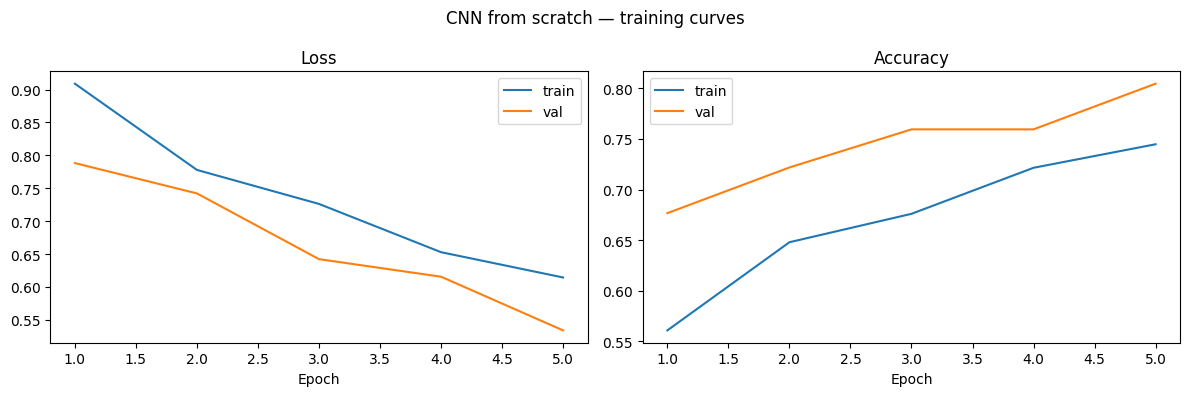


=== CNN Test Evaluation ===

Test accuracy: 0.7891  (78.9%)



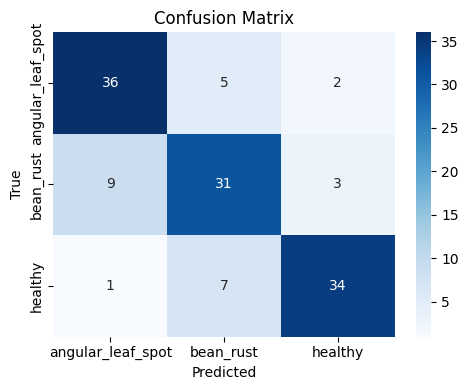

In [31]:
plot_history(cnn_history, title="CNN from scratch — training curves")

print("\n=== CNN Test Evaluation ===")
cnn_test_acc, cnn_preds, cnn_labels = evaluate(cnn_model, cnn_test_loader, DEVICE)


After 5 epochs our CNN trained from scratch achieves an accuracy of ~ 77%.
This is not too bad, but we can improve our approach by using a pre-trained model and fine-tuning it on our dataset.

---

# Part 3 — Transfer Learning with a Pretrained ViT

## Background: Why Transfer Learning?

`google/vit-base-patch16-224` is a Vision Transformer trained on ImageNet-21k
(14 M images, 21 843 classes) and then fine-tuned on ImageNet-1k.  Its weights
encode extraordinarily rich visual representations.

Note that the ImageNet dataset does not contain specific images of bean leaves, bean rust or leaf spots.
Nonetheless, the model needs far fewer epochs to specialise because the model already "knows" what leaves, textures, colours, and shapes
look like.


**Strategy**:
We start from a ViT model pretrained on ImageNet (1000 classes).
Our bean dataset contains only 3 classes, so the original classifier
layer (768 -> 1000) cannot be reused. Transformers therefore loads all
pretrained ViT weights, replaces the final classifier with a new
randomly initialized layer (768 -> 3), and warns about the size mismatch.
This is expected and is the standard transfer-learning workflow.




In [35]:
VIT_CHECKPOINT = "google/vit-base-patch16-224"

print("Loading pretrained ViT ...")
vit_processor = ViTImageProcessor.from_pretrained(VIT_CHECKPOINT)

vit_model = ViTForImageClassification.from_pretrained(
    VIT_CHECKPOINT,
    num_labels=3,
    ignore_mismatched_sizes=True,   # classifier head size changes 1000->3
    id2label={i: n for i, n in enumerate(CLASS_NAMES)},
    label2id={n: i for i, n in enumerate(CLASS_NAMES)},
).to(DEVICE)

total_vit  = sum(p.numel() for p in vit_model.parameters())
print(f"ViT total parameters: {total_vit:,}")
print("Classifier head:", vit_model.classifier)


Loading pretrained ViT ...


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT total parameters: 85,800,963
Classifier head: Linear(in_features=768, out_features=3, bias=True)


In [36]:
# ViT processor normalises to [-1, 1] with mean/std = 0.5
VIT_MEAN = vit_processor.image_mean
VIT_STD  = vit_processor.image_std

vit_train_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(VIT_MEAN, VIT_STD),
])
vit_val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(VIT_MEAN, VIT_STD),
])

vit_train_loader = DataLoader(
    BeansDataset(beans["train"],      vit_train_tf),
    batch_size=32, shuffle=True,  num_workers=0, pin_memory=True
)
vit_val_loader   = DataLoader(
    BeansDataset(beans["validation"], vit_val_tf),
    batch_size=32, shuffle=False, num_workers=0
)
vit_test_loader  = DataLoader(
    BeansDataset(beans["test"],       vit_val_tf),
    batch_size=32, shuffle=False, num_workers=0
)

# ── forward wrapper: HuggingFace models return an object, not a raw tensor ──
def vit_forward(model, images):
    return model(pixel_values=images).logits

print("ViT data loaders ready.")


ViT data loaders ready.


In [37]:
# We use a small LR because the pretrained backbone should not change much.
vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=1e-3)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    vit_optimizer, T_max=NUM_EPOCHS
)

def run_epoch_vit(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = vit_forward(model, images)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


def train_loop_vit(model, train_loader, val_loader, optimizer, scheduler,
                   num_epochs, device, name="ViT"):
    criterion = nn.CrossEntropyLoss()
    history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = run_epoch_vit(model, train_loader, optimizer,
                                        criterion, device, train=True)
        vl_loss, vl_acc = run_epoch_vit(model, val_loader,   optimizer,
                                        criterion, device, train=False)
        if scheduler: scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc" ].append(tr_acc)
        history["val_loss"  ].append(vl_loss)
        history["val_acc"   ].append(vl_acc)
        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = deepcopy(model.state_dict())
        print(f"[{name}] Epoch {epoch:2d}/{num_epochs} | "
              f"train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
              f"val loss {vl_loss:.4f}  acc {vl_acc:.3f}")
    model.load_state_dict(best_state)
    return history, best_acc


print("Fine-tuning ViT for", NUM_EPOCHS, "epochs (~ 5 minutes on GPU)...\n")
vit_history, vit_best_val = train_loop_vit(
    vit_model, vit_train_loader, vit_val_loader,
    vit_optimizer, vit_scheduler, NUM_EPOCHS, DEVICE, name="ViT"
)


Fine-tuning ViT for 5 epochs (~ 5 minutes on GPU)...

[ViT] Epoch  1/5 | train loss 0.5803  acc 0.773 | val loss 0.2036  acc 0.962
[ViT] Epoch  2/5 | train loss 0.1395  acc 0.959 | val loss 0.0920  acc 0.977
[ViT] Epoch  3/5 | train loss 0.0609  acc 0.984 | val loss 0.0571  acc 0.977
[ViT] Epoch  4/5 | train loss 0.0388  acc 0.989 | val loss 0.0728  acc 0.970
[ViT] Epoch  5/5 | train loss 0.0325  acc 0.995 | val loss 0.0593  acc 0.970


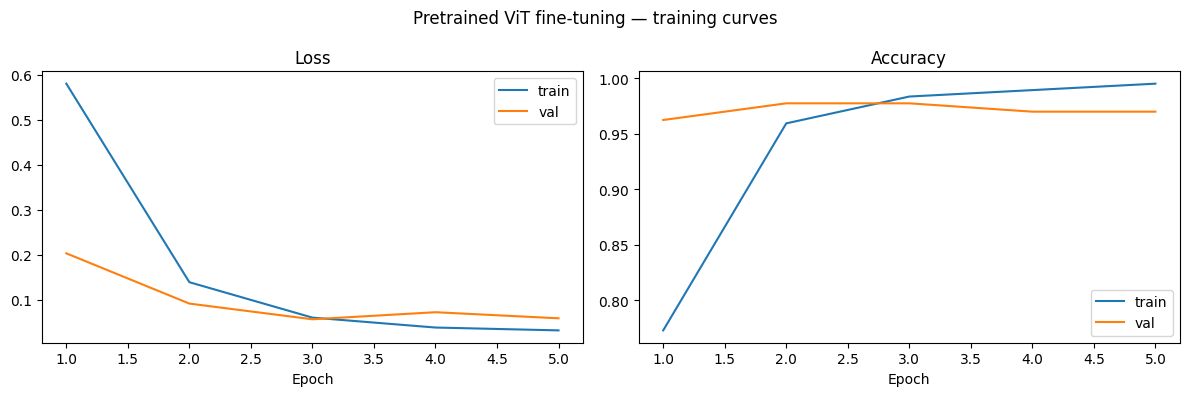


=== ViT Test Evaluation ===

Test accuracy: 0.9453  (94.5%)



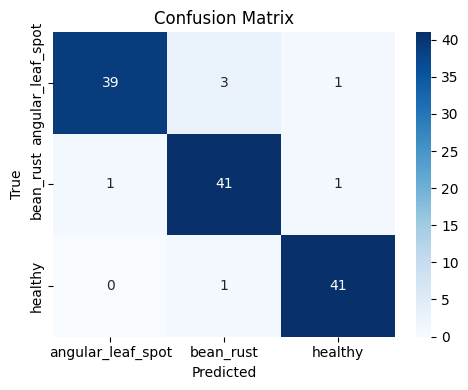


  CNN from scratch  - test accuracy: 78.9%
  ViT (pretrained)  - test accuracy: 94.5%



In [38]:
plot_history(vit_history, title="Pretrained ViT fine-tuning — training curves")

print("\n=== ViT Test Evaluation ===")
vit_test_acc, vit_preds, vit_labels = evaluate(
    vit_model, vit_test_loader, DEVICE, forward_fn=vit_forward
)

print("\n" + "="*52)
print(f"  CNN from scratch  - test accuracy: {cnn_test_acc*100:.1f}%")
print(f"  ViT (pretrained)  - test accuracy: {vit_test_acc*100:.1f}%")
print("="*52)
print()



## Key Takeaways

The ViT converges much faster because it starts from weights pretrained on ImageNet, whereas the CNN must learn all visual features from scratch using only about 1,000 training images.

This highlights an important lesson: **pretraining often has a larger impact than the choice of architecture itself**, especially when labelled data is scarce.

It is also important to note that this is not a purely fair comparison of CNNs and ViTs. We compare:
- a CNN trained from scratch, versus
- a pretrained ViT.

A fairer architectural comparison would be:
- pretrained CNN vs. pretrained ViT, or
- CNN from scratch vs. ViT from scratch.

The main takeaway is that **transfer learning can dramatically improve performance when only limited training data is available.**

---

## References

- Dosovitskiy et al. "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." *ICLR 2021*. [arXiv:2010.11929](https://arxiv.org/abs/2010.11929)
- Vaswani et al. "Attention is All You Need." *NeurIPS 2017*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
- Makerere AI Lab. "Bean Disease Dataset." *Hugging Face Datasets*. [AI-Lab-Makerere/beans](https://huggingface.co/datasets/AI-Lab-Makerere/beans)
- Google Brain. `google/vit-base-patch16-224`. *Hugging Face Model Hub*. [model card](https://huggingface.co/google/vit-base-patch16-224)
